In [2]:
# IMPORTING LIBRARIES

import numpy as np
import pandas as pd
import scipy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# READING FILE

df = pd.read_csv('Sample.csv') # here we are importing the csv file
print(df.head()) # print out the first 5 lines of sample file

data= df['Salary'] # read an specific column from the dataframe
print(data.head())

   Person  Age  Gender       State  Children  Salary  Opinion
0       1   35    Male   Minnesota         1   65400        5
1       2   61  Female       Texas         2   62000        1
2       3   35    Male        Ohio         0   63200        3
3       4   37    Male     Florida         2   52000        5
4       5   32  Female  California         3   81400        1
0    65400
1    62000
2    63200
3    52000
4    81400
Name: Salary, dtype: int64


# DIAGNOSTICS

EXAMPLE: Variable/Column Descriptions and Breakdown

Column: "age"
Description: Age of the individual in years.
Type: Numerical

Column: "gender"
Description: Gender of the individual.
Type: Categorical
Categories: ['Male', 'Female', 'Other']

Column: "income"
Description: Annual income in USD.
Type: Numerical

Column: "occupation"
Description: Job title of the individual.
Type: Categorical
Categories: ['Engineer', 'Doctor', 'Artist']

In [88]:
data = pd.read_csv('healthData.csv')
data.replace({'heart_attack': {0: False, 1: True}, 'work_out_habit':{None: 'None'}}, inplace=True)
data = data.astype({'heart_attack': 'category', 'work_out_habit': 'category', 'gender': 'category',
              'smoking_habit': 'category', 'education': 'category'})
data.dtypes

C:\Users\Julian\AppData\Local\Temp\ipykernel_9748\747133855.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'heart_attack': {0: False, 1: True}, 'work_out_habit':{None: 'None'}}, inplace=True)


age                float64
gender            category
smoking_habit     category
work_out_habit    category
heart_attack      category
salary             float64
education         category
dtype: object

In [75]:
# Variables for numerical 

numerical = data[['age', 'salary']]
categorical = data.drop(['age', 'salary'], axis=1)

# Calculate descriptive statistics
mean = numerical.mean()
median = numerical.median()
maximum = numerical.max()
minimum = numerical.min()
variance = numerical.var() #square of std dev
std_dev = numerical.std() #requires mean
skewness = numerical.skew()
kurtosis = numerical.kurtosis()
distribution_range = maximum - minimum

# Display the results
print(f'Mean: \n{mean}\n')
print(f'Median: \n{median}\n')
print(f'Maximum: \n{maximum}\n')
print(f'Minimum: \n{minimum}\n')
print(f'Variance: \n{variance}\n')
print(f'Standard Deviation: \n{std_dev}\n')
print(f'Skewness: \n{skewness}\n')

print(f'Kurtosis: \n{kurtosis}\n') 
# It helps in understanding the distribution's extremities
# particularly how heavy (has extreme values) or light the tails are compared to a normal distribution
print(f'Range: \n{distribution_range}\n')

Mean: 
age          51.388889
salary    93070.790055
dtype: float64

Median: 
age          51.0
salary    87481.0
dtype: float64

Maximum: 
age          130.0
salary    400000.0
dtype: float64

Minimum: 
age          23.0
salary    23747.0
dtype: float64

Variance: 
age       2.016580e+02
salary    2.103001e+09
dtype: float64

Standard Deviation: 
age          14.200633
salary    45858.491116
dtype: float64

Skewness: 
age       2.388808
salary    3.410983
dtype: float64

Kurtosis: 
age        9.828723
salary    17.923455
dtype: float64

Range: 
age          107.0
salary    376253.0
dtype: float64



C:\Users\Julian\AppData\Local\Temp\ipykernel_9748\3609725104.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'heart_attack': {0: False, 1: True}}, inplace=True)


In [1]:
Q1_salary = data['salary'].quantile(0.25)
Q3_salary = data['salary'].quantile(0.75)
IQR_salary = Q3_salary - Q1_salary
lower_bound_salary = Q1_salary - 1.5 * IQR_salary
upper_bound_salary = Q3_salary + 1.5 * IQR_salary
# Remove outliers from 'salary'
healthData = data[(data['salary'] >= lower_bound_salary) & (data['salary'] <= upper_bound_salary)]

print(healthData)


NameError: name 'data' is not defined

In [98]:
print(data.head()) # print out the first 5 lines of sample file

gender_cat = data['gender'].cat.categories.values
print(f'List of Gender Categories: {gender_cat}')

smoking_cat = data['smoking_habit'].cat.categories.values
print(f'List of Smoking Categories: {smoking_cat}')

HeartAttack_cat = data['heart_attack'].cat.categories.values
print(f'List of Heart Attack Categories: {HeartAttack_cat}')

education_cat = data['education'].cat.categories.values
print(f'List of Education Categories: {education_cat}')

workout_cat = data['work_out_habit'].cat.categories.values
print(f'List of Workout Categories: {workout_cat}')

    age  gender smoking_habit work_out_habit heart_attack    salary  \
0  59.0  Female  Heavy Smoker           None        False  127387.0   
1  48.0  Female    Non-Smoker           None        False   64314.0   
2  56.0  Female    Non-Smoker           None        False   67394.0   
3  65.0  Female  Light Smoker           None        False   71546.0   
4  47.0    Male    Non-Smoker           None         True   39666.0   

     education  
0   Bachelor's  
1          PhD  
2          PhD  
3   Bachelor's  
4  High School  
List of Gender Categories: ['Female' 'Male']
List of Smoking Categories: ['Heavy Smoker' 'Light Smoker' 'Non-Smoker']
List of Heart Attack Categories: [False  True]
List of Education Categories: ["Bachelor's" 'High School' "Master's" 'PhD']
List of Workout Categories: ['None' 'Occasionally' 'Regularly']


In [76]:
# Using describe function
summary = data.describe()
print(summary)

              age         salary
count  180.000000     181.000000
mean    51.388889   93070.790055
std     14.200633   45858.491116
min     23.000000   23747.000000
25%     43.000000   64073.000000
50%     51.000000   87481.000000
75%     56.000000  106173.000000
max    130.000000  400000.000000


In [8]:
# Skewness/Kurtosis Correction

df_1 = df.drop(['Person', 'State', 'Gender'], axis=1)

##manually remove columns that interfere with calculation of skewness/kurtosis, 
##axis=0 rows/axis=1 columns

print(df_1)
skewness = df_1.skew()
kurtosis = df_1.kurtosis()

print(skewness)
print(kurtosis)

    Age  Children  Salary  Opinion
0    35         1   65400        5
1    61         2   62000        1
2    35         0   63200        3
3    37         2   52000        5
4    32         3   81400        1
5    33         3   46300        5
6    65         2   49600        1
7    45         1   45900        5
8    40         3   47700        4
9    32         1   59900        4
10   57         1   48100        4
11   38         0   58100        3
12   37         2   56000        1
13   42         2   53400        1
14   38         2   39000        2
15   48         1   61500        2
16   40         0   37700        1
17   57         2   36700        4
18   44         2   45200        3
19   40         0   59000        4
20   21         2   54300        2
21   49         1   62100        4
22   34         0   78000        3
23   49         0   43200        5
24   40         1   44500        3
25   38         1   43300        1
26   27         3   45400        2
27   63         2   

In [60]:
# Percentiles (25th, 50th, 75th percentiles) and IQR
percentile_25 = data.quantile(0.25)
percentile_50 = data.quantile(0.50)  # Same as median
percentile_75 = data.quantile(0.75)
percentile_1 = data.quantile(0.01)
percentile_10 = data.quantile(0.10)
percentile_90 = data.quantile(0.90)
percentile_99 = data.quantile(0.99)

Inter_Quartile_Range = percentile_75 - percentile_25

print(f'1st Percentile (Median): {percentile_1}')
print(f'25th Percentile: {percentile_25}')
print(f'50th Percentile (Median): {percentile_50}')
print(f'75th Percentile: {percentile_75}')

print(f'10th Percentile: {percentile_10}')
print(f'90th Percentile: {percentile_90}')
print(f'99th Percentile: {percentile_99}')

print(f'IQR: {Inter_Quartile_Range}')

1st Percentile (Median): 32653.0
25th Percentile: 44675.0
50th Percentile (Median): 50800.0
75th Percentile: 59675.0
10th Percentile: 38870.0
90th Percentile: 63420.0
99th Percentile: 80414.0
IQR: 15000.0


# MISSING VALUES

In [32]:
# Reading Dataframe
df = pd.read_csv('Student_Grades.csv')

# # Show the dataset
print("Original DataFrame:")
print(df)

Original DataFrame:
   StudentID     Name    Age  MathScore  EnglishScore  ScienceScore  \
0          1    Alice   20.0       85.0          90.0          88.0   
1          2      Bob   21.0       95.0          88.0          90.0   
2          3  Charlie   19.0       40.0          50.0           NaN   
3          4    David   23.0       78.0           NaN          82.0   
4          5      Eve  200.0       88.0          92.0          89.0   
5          6    Frank    NaN       72.0          85.0          70.0   
6          7    Grace   20.0        NaN          78.0          76.0   
7          8   Hannah   21.0       85.0          90.0          95.0   
8          9      Ivy   22.0       91.0          80.0          93.0   
9         10     Jack   20.0       77.0          75.0          65.0   

   Attendance  
0        95.0  
1         NaN  
2        80.0  
3        85.0  
4        95.0  
5        60.0  
6        92.0  
7        96.0  
8        97.0  
9        58.0  


In [33]:
# DROPPING ROWS

df_rows_dropped = df.dropna()

print("\nDataFrame after removing rows with missing values:")
print(df_rows_dropped)

#if rows contain outliers (that deter from intent of analysis), drop rows
#else, opt for alternative options


DataFrame after removing rows with missing values:
   StudentID    Name    Age  MathScore  EnglishScore  ScienceScore  Attendance
0          1   Alice   20.0       85.0          90.0          88.0        95.0
4          5     Eve  200.0       88.0          92.0          89.0        95.0
7          8  Hannah   21.0       85.0          90.0          95.0        96.0
8          9     Ivy   22.0       91.0          80.0          93.0        97.0
9         10    Jack   20.0       77.0          75.0          65.0        58.0


In [34]:
# DROPPING COLUMNS

df_columns_dropped = df.dropna(axis=1)

print("\nDataFrame after removing columns with missing values:")
print(df_columns_dropped)

#used if need to remove columns that are obstructing a calculation


DataFrame after removing columns with missing values:
   StudentID     Name
0          1    Alice
1          2      Bob
2          3  Charlie
3          4    David
4          5      Eve
5          6    Frank
6          7    Grace
7          8   Hannah
8          9      Ivy
9         10     Jack


In [51]:
# REPLACE WITH MEAN

df = pd.read_csv('Student_Grades.csv')

##FOR REPLACING ENTIRE TABLE'S MISSING VALUES

# df_mean_filled = df.fillna(df.mean(numeric_only=True))

# print("\nDataFrame after filling missing values with mean:")
# print(df_mean_filled)

##FOR REPLACING INDIVIDUAL COLUMN'S MISSING VALUES

ColumnsToDrop = ['MathScore', 'EnglishScore', 'ScienceScore'] 

df_mean_filled = df.fillna(df[ColumnsToDrop].mean(numeric_only=True))

print("\nDataFrame after filling missing values with mean:")
print(df_mean_filled)

#easy fix for a small dataset, UNLESS distribution is not normal


DataFrame after filling missing values with mean:
   StudentID     Name    Age  MathScore  EnglishScore  ScienceScore  \
0          1    Alice   20.0       85.0     90.000000     88.000000   
1          2      Bob   21.0       95.0     88.000000     90.000000   
2          3  Charlie   19.0       40.0     50.000000     83.111111   
3          4    David   23.0       78.0     80.888889     82.000000   
4          5      Eve  200.0       88.0     92.000000     89.000000   
5          6    Frank    NaN       72.0     85.000000     70.000000   
6          7    Grace   20.0       79.0     78.000000     76.000000   
7          8   Hannah   21.0       85.0     90.000000     95.000000   
8          9      Ivy   22.0       91.0     80.000000     93.000000   
9         10     Jack   20.0       77.0     75.000000     65.000000   

   Attendance  
0        95.0  
1         NaN  
2        80.0  
3        85.0  
4        95.0  
5        60.0  
6        92.0  
7        96.0  
8        97.0  
9      

In [36]:
# REPLACE WITH MEDIAN

df_median_filled = df.fillna(df.median(numeric_only=True))

print("\nDataFrame after filling missing values with median:")
print(df_median_filled)

#easy fix for a small dataset, UNLESS distribution is not normal


DataFrame after filling missing values with median:
   StudentID     Name    Age  MathScore  EnglishScore  ScienceScore  \
0          1    Alice   20.0       85.0          90.0          88.0   
1          2      Bob   21.0       95.0          88.0          90.0   
2          3  Charlie   19.0       40.0          50.0          88.0   
3          4    David   23.0       78.0          85.0          82.0   
4          5      Eve  200.0       88.0          92.0          89.0   
5          6    Frank   21.0       72.0          85.0          70.0   
6          7    Grace   20.0       85.0          78.0          76.0   
7          8   Hannah   21.0       85.0          90.0          95.0   
8          9      Ivy   22.0       91.0          80.0          93.0   
9         10     Jack   20.0       77.0          75.0          65.0   

   Attendance  
0        95.0  
1        92.0  
2        80.0  
3        85.0  
4        95.0  
5        60.0  
6        92.0  
7        96.0  
8        97.0  
9    

In [37]:
# REPLACE WITH FORWARD FILL

df_ffill = df.fillna(method='ffill')

print("\nDataFrame after forward filling missing values:")
print(df_ffill)

#Forward fill used if data is sequential


DataFrame after forward filling missing values:
   StudentID     Name    Age  MathScore  EnglishScore  ScienceScore  \
0          1    Alice   20.0       85.0          90.0          88.0   
1          2      Bob   21.0       95.0          88.0          90.0   
2          3  Charlie   19.0       40.0          50.0          90.0   
3          4    David   23.0       78.0          50.0          82.0   
4          5      Eve  200.0       88.0          92.0          89.0   
5          6    Frank  200.0       72.0          85.0          70.0   
6          7    Grace   20.0       72.0          78.0          76.0   
7          8   Hannah   21.0       85.0          90.0          95.0   
8          9      Ivy   22.0       91.0          80.0          93.0   
9         10     Jack   20.0       77.0          75.0          65.0   

   Attendance  
0        95.0  
1        95.0  
2        80.0  
3        85.0  
4        95.0  
5        60.0  
6        92.0  
7        96.0  
8        97.0  
9        

C:\Users\Julian\AppData\Local\Temp\ipykernel_9748\3752565953.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method='ffill')


In [38]:
# REPLACE WITH BACK FILL

df_bfill = df.fillna(method='bfill')

print("\nDataFrame after backward filling missing values:")
print(df_bfill)

#Backward fill used if data is sequential


DataFrame after backward filling missing values:
   StudentID     Name    Age  MathScore  EnglishScore  ScienceScore  \
0          1    Alice   20.0       85.0          90.0          88.0   
1          2      Bob   21.0       95.0          88.0          90.0   
2          3  Charlie   19.0       40.0          50.0          82.0   
3          4    David   23.0       78.0          92.0          82.0   
4          5      Eve  200.0       88.0          92.0          89.0   
5          6    Frank   20.0       72.0          85.0          70.0   
6          7    Grace   20.0       85.0          78.0          76.0   
7          8   Hannah   21.0       85.0          90.0          95.0   
8          9      Ivy   22.0       91.0          80.0          93.0   
9         10     Jack   20.0       77.0          75.0          65.0   

   Attendance  
0        95.0  
1        80.0  
2        80.0  
3        85.0  
4        95.0  
5        60.0  
6        92.0  
7        96.0  
8        97.0  
9       

C:\Users\Julian\AppData\Local\Temp\ipykernel_9748\3199896147.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method='bfill')


# OUTLIERS

In [39]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)

df = pd.read_csv('Student_Grades.csv')

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds (must be within these margins)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR 

In [61]:
# Detect outliers w/IQR

df = pd.read_csv('Student_Grades.csv')

print(df['Age'] < lower_bound)
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

print(f"\nOutliers detected in Age column (using IQR):\n{outliers}")

# Remove outliers w/IQR

df_no_outliers = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

print("\nDataFrame after removing outliers:")
print(df_no_outliers)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: Age, dtype: bool

Outliers detected in Age column (using IQR):
   StudentID Name    Age  MathScore  EnglishScore  ScienceScore  Attendance
4          5  Eve  200.0       88.0          92.0          89.0        95.0

DataFrame after removing outliers:
   StudentID     Name   Age  MathScore  EnglishScore  ScienceScore  Attendance
0          1    Alice  20.0       85.0          90.0          88.0        95.0
1          2      Bob  21.0       95.0          88.0          90.0         NaN
2          3  Charlie  19.0       40.0          50.0           NaN        80.0
3          4    David  23.0       78.0           NaN          82.0        85.0
6          7    Grace  20.0        NaN          78.0          76.0        92.0
7          8   Hannah  21.0       85.0          90.0          95.0        96.0
8          9      Ivy  22.0       91.0          80.0          93.0        97.0
9

In [41]:
# #3.2. Capping Outliers (Setting Upper/Lower Bound on Outliers)
# Instead of removing outliers, you can cap them at the upper or lower bounds.

df = pd.read_csv('Student_Grades.csv')

# Cap the outliers in the Age column
df['Age_capped'] = df['Age'].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

print("\nDataFrame after capping outliers in Age column:")
print(df['Age'], ['Age_capped'])


DataFrame after capping outliers in Age column:
0     20.0
1     21.0
2     19.0
3     23.0
4    200.0
5      NaN
6     20.0
7     21.0
8     22.0
9     20.0
Name: Age, dtype: float64 ['Age_capped']


In [43]:
# z-scores

df = pd.read_csv('Student_Grades.csv')

ages = df['Age'].dropna()
z_scores = np.abs(stats.zscore(ages))  # dropna to ignore NaNs
threshold = 3  # Common threshold for Z-scores
outliers_z = ages.iloc[(z_scores > threshold).values]

print(z_scores)

print("\nOutliers detected in Age column (using Z-score):")
print(outliers_z)

0    0.366793
1    0.349045
2    0.384541
3    0.313549
4    2.827858
6    0.366793
7    0.349045
8    0.331297
9    0.366793
Name: Age, dtype: float64

Outliers detected in Age column (using Z-score):
Series([], Name: Age, dtype: float64)


# VISIUALIZATION

<Axes: xlabel='gender', ylabel='count'>

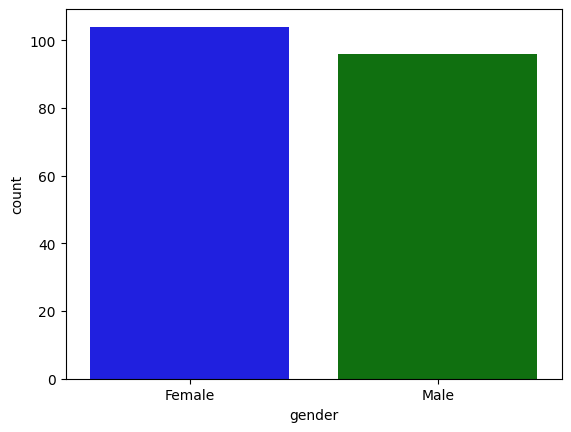

In [99]:
#Bar Chart
# USED FOR CATEGORICAL DATA

sns.countplot(data=df, x='gender', hue='gender',
              palette={'Male':'green', 'Female':'blue'})
# #hue creates different colors for the bars

# sns.countplot(data=df, x='gender', hue='gender',
#               palette={'group A':'green', 'group B':'blue', 'group C':'yellow',
#                         'group D':'red', 'group E':'orange'})

# plt.show()


<Axes: xlabel='math_score'>

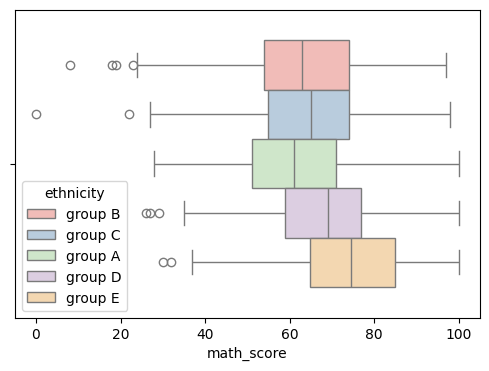

In [44]:
#Boxplot
# explore math distribution across ethnicity

df = pd.read_csv('student.csv')

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='math_score', hue='ethnicity', palette='Pastel1')

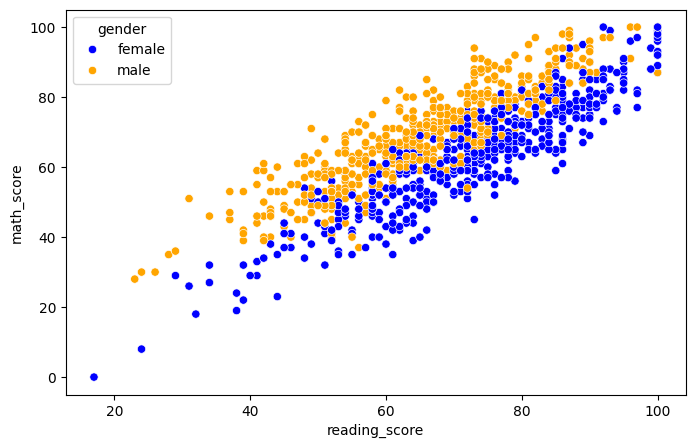

In [45]:
#Scatterplot
# explore relationship between math_score and reading_score

df = pd.read_csv('student.csv')

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='reading_score', y='math_score',
                hue='gender', palette={'female':'blue' , 'male':'orange'})
plt.show()

   gender ethnicity  parental_education         lunch test_preparation_course  \
0  female   group B   bachelor's degree      standard                    none   
1  female   group C        some college      standard               completed   
2  female   group B     master's degree      standard                    none   
3    male   group A  associate's degree  free/reduced                    none   
4    male   group C        some college      standard                    none   

   math_score  reading_score  writing_score  
0          72             72             74  
1          69             90             88  
2          90             95             93  
3          47             57             44  
4          76             78             75  


<Axes: xlabel='math_score', ylabel='Count'>

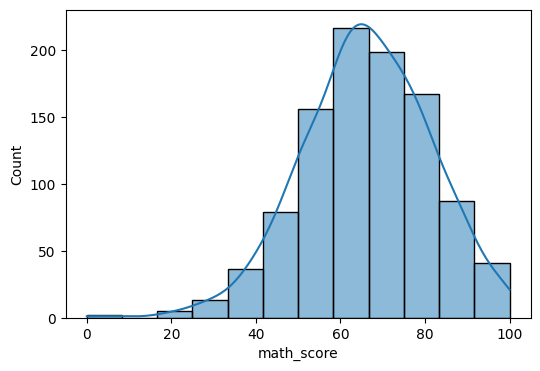

In [100]:
# Histogram
df = pd.read_csv('student.csv') # here we are importing the csv file
print(df.head()) # print out the first 5 lines of sample file

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='math_score',
             binwidth=8, fill=True, kde=True)

# plt.figure(figsize=(6,4))
# sns.histplot(data=df, x='math_score', hue='gender',
#              palette={'female':'blue' , 'male':'orange'},
#              binwidth=8, fill=True, kde=True)

      Date     Gold  Platinum
0  1986-12  391.595    465.29
1  1987-12  487.079    556.63
2  1988-12  419.248    530.29
3  1989-12  409.655    509.68
4  1990-12  378.161    471.29


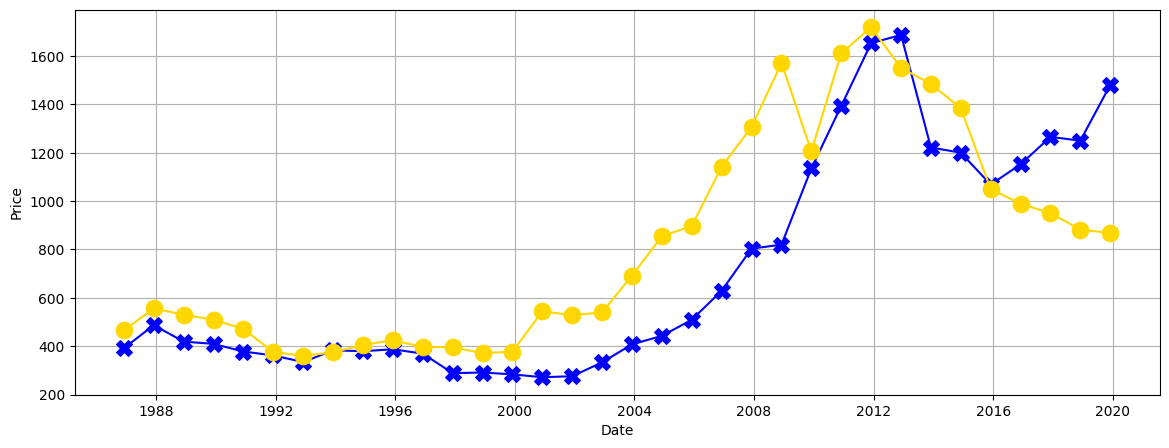

In [63]:
#Time Series Lineplot

df = pd.read_csv('annual_gold.csv') # here we are importing the csv file
print(df.head()) # print out the first 5 lines of sample file

# manually change the data type for 'Date', will make the x-axis labels more legible
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='Date', y='Gold', marker='X', 
             markersize=12, mfc='blue', mec='blue', c='blue')

#ONLY NEED ONE VARIABLE

sns.lineplot(data=df, x='Date', y='Platinum', marker='o', 
             markersize=12, mfc='gold', mec='gold', c='gold')
plt.ylabel('Price')
plt.grid()
plt.show()

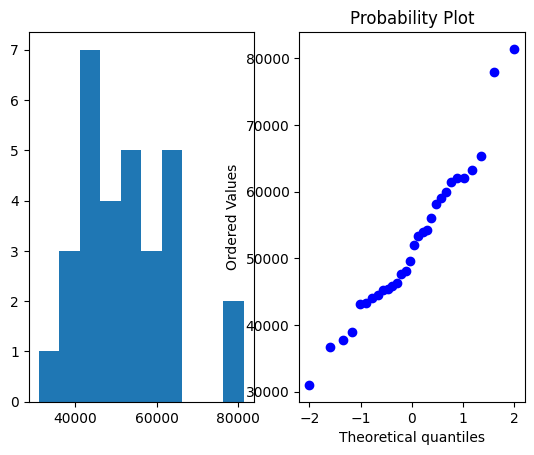

In [23]:
# Histplot and Q-Q/Probability Plot

salary = df["Salary"]
ax1, ax2 = plt.figure().subplots(1, 2)
ax1.hist(salary)
sc.stats.probplot(salary, sparams=(), dist='norm', plot=ax2, fit=False, rvalue=False)
plt.show()